# Creative MNIST sampling — pixel-space $p$ via Tweedie, $\lambda$-tempered SMC

This notebook runs the repo's **pixel path** (previously only scaffolded) on real images. We sample from

$$q_\lambda(x)\;\propto\;p(x)\,\exp\!\big(\lambda\, f(x)\big),\qquad f(x)=\frac{\mathbb{E}_{r}\,D_{\mathrm{IEM}}^2(x,x_r)}{\mathbb{E}_{r\ne s}\,D_{\mathrm{IEM}}^2(x_r,x_s)},$$

where $f$ is the normalized **global-IEM distance** from $x$ to a reference set drawn from the data distribution $p$ (real MNIST digits). Raising the temperature $\lambda$ pushes mass **off the data manifold** → progressively more *creative* digits. At $\lambda=0$ we recover samples from $p$ itself.

**How $p$ enters — Tweedie.** We never write $\log p(x)$ in closed form. The base distribution's *geometry* is defined entirely by a pretrained MNIST **UNet** through **Tweedie's formula**: for the noised observation $y_\sigma = x + \sigma\varepsilon$, the score is $\nabla\log p_\sigma(y_\sigma) = (D(y_\sigma,\sigma)-y_\sigma)/\sigma^2$, where $D(y_\sigma,\sigma)=\mathbb{E}[x\mid y_\sigma]$ is the MMSE denoiser. This score is what the IEM distance integrates, and the same denoiser drives the generator $G$ that the pCN kernel moves in.

**The model.** We use the HuggingFace checkpoint [`1aurent/ddpm-mnist`](https://huggingface.co/1aurent/ddpm-mnist): *a very lightweight `UNet2DModel` (28×28×1) trained on MNIST as an unconditional DDPM* — it is **not** an EDM model, and you can't pick which digit it generates. Being a **VP / $\varepsilon$-prediction** DDPM, the Tweedie adapter in §1 bridges it to the MMSE **denoiser** $D(y_\sigma,\sigma)=\mathbb{E}[x\mid y_\sigma]$ in the VE convention — the interface the repo's **EDM-style prob-flow** sampler and score functions consume (a standard k-diffusion-style wrapper). Everything downstream — `edm_score_fn`, `edm_generator`, `SquaredGlobalIEMDistance`, `PCNKernel`, `smc_sample` — is reused **unchanged**. (The `edm_*` names refer to the repo's EDM prob-flow ODE integrator, not to the checkpoint.)

> **CPU note.** Each pCN step runs a multi-step ODE through the UNet *and* evaluates the IEM reward (≈ `R × n_gamma` UNet forwards). The defaults below are tuned small for CPU; the full sweep still takes tens of minutes. Scale `N`, `R`, `n_gamma`, `num_eps`, `n_steps` up on a GPU.

## Setup — imports and the pretrained MNIST UNet

`float32` (the pixel path; the 2D toy notebooks use `float64`). We load the diffusers `UNet2DModel` (the lightweight DDPM checkpoint). The `import safetensors.torch` line is a shim: diffusers 0.27 does a bare `import safetensors` and then calls `safetensors.torch.load_file`, so we populate that submodule attribute first.

In [1]:
import sys, os, math, time
sys.path.insert(0, '..')                       # notebook lives in creativity-measure/notebooks/
import torch
from creativity_measure import set_default_dtype
set_default_dtype(torch.float32)               # pixel path is float32 (the 2D toy used float64)
torch.manual_seed(0)
device = torch.device('cpu')

import safetensors.torch  # noqa: F401  — populate safetensors.torch for the diffusers 0.27 loader
from diffusers import UNet2DModel
unet = UNet2DModel.from_pretrained('1aurent/ddpm-mnist').to(device).eval()   # lightweight DDPM UNet

C, H, W = 1, 28, 28
D = C * H * W                                  # flat pixel dim = 784; img_shape = (1, 28, 28)
print('loaded UNet2DModel:', f'{unet.config.sample_size}px', f'{unet.config.in_channels}ch',
      '| params:', sum(p.numel() for p in unet.parameters()))

/usr/local/Caskroom/miniconda/base/envs/creativity-measure/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


/usr/local/Caskroom/miniconda/base/envs/creativity-measure/lib/python3.12/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


loaded UNet2DModel: 28px 1ch | params: 1065153


## 1. Tweedie adapter — DDPM/UNet $\varepsilon$-model $\to$ MMSE denoiser $D(y_\sigma,\sigma)$

The UNet predicts noise under the DDPM **variance-preserving** schedule $x_t=\sqrt{\bar\alpha_t}\,x_0+\sqrt{1-\bar\alpha_t}\,\varepsilon$. The repo's sampler works in the **variance-exploding** convention $y_\sigma = x_0 + \sigma\varepsilon$. The two match at $\bar\alpha = 1/(1+\sigma^2)$, i.e.

$$\sigma(t)=\sqrt{\tfrac{1-\bar\alpha_t}{\bar\alpha_t}},\qquad x_t = \tfrac{y_\sigma}{\sqrt{1+\sigma^2}},\qquad D(y_\sigma,\sigma)=y_\sigma-\sigma\,\varepsilon_\theta\!\Big(\tfrac{y_\sigma}{\sqrt{1+\sigma^2}},\,t(\sigma)\Big).$$

That last expression is exactly Tweedie's posterior mean $\mathbb{E}[x_0\mid y_\sigma]$, i.e. the MMSE denoiser in the form the repo's EDM-style sampler expects. We build the discrete $\sigma(t)$ grid from the linear-$\beta$ schedule and a continuous `sigma_to_t` interpolator so the denoiser accepts any $\sigma$ in range.

In [2]:
# DDPM linear-beta schedule -> continuous VE sigma(t) grid  (1aurent/ddpm-mnist config)
betas = torch.linspace(1e-4, 0.02, 1000)
alpha_bar = torch.cumprod(1.0 - betas, 0)
sigmas_ddpm = torch.sqrt((1 - alpha_bar) / alpha_bar)          # increasing in t
SIGMA_MIN, SIGMA_MAX = float(sigmas_ddpm[0]), float(sigmas_ddpm[-1])

def sigma_to_t(sigma):
    """Continuous timestep t s.t. sigma(t) = sigma, via linear interp over the increasing grid."""
    s = torch.as_tensor(sigma, dtype=torch.float32).flatten().clamp(SIGMA_MIN, SIGMA_MAX)
    idx = torch.searchsorted(sigmas_ddpm, s).clamp(1, 999)
    lo, hi = sigmas_ddpm[idx - 1], sigmas_ddpm[idx]
    frac = (s - lo) / (hi - lo).clamp_min(1e-12)
    return idx - 1 + frac                                      # float timesteps in [0, 999]

@torch.no_grad()
def denoiser(y_sigma, sigma):
    """VE-convention MMSE denoiser D(y_sigma, sigma) = E[x | y_sigma] from the DDPM eps-UNet (Tweedie)."""
    B = y_sigma.shape[0]
    sig = torch.as_tensor(sigma, dtype=torch.float32, device=y_sigma.device).flatten()
    if sig.numel() == 1:
        sig = sig.expand(B)
    sig4 = sig.view(B, 1, 1, 1)
    c_in = 1.0 / torch.sqrt(1.0 + sig4 ** 2)                   # x_t = y_sigma * sqrt(alpha_bar)
    eps = unet(y_sigma * c_in, sigma_to_t(sig)).sample         # UNet2DModel returns .sample (eps-prediction)
    return y_sigma - sig4 * eps                                # Tweedie posterior mean

# sanity: finite, correct shape, sensible at a few noise levels
_y = torch.randn(4, 1, 28, 28)
print(f'sigma range: [{SIGMA_MIN:.4f}, {SIGMA_MAX:.2f}]')
for _s in [SIGMA_MIN, 1.0, 10.0, SIGMA_MAX]:
    _d = denoiser(_y, torch.tensor(_s))
    print(f'  D(., sigma={_s:8.3f}): finite={torch.isfinite(_d).all().item()} '
          f'shape={tuple(_d.shape)} mean={_d.mean():+.3f}')

sigma range: [0.0100, 157.41]
  D(., sigma=   0.010): finite=True shape=(4, 1, 28, 28) mean=-0.020
  D(., sigma=   1.000): finite=True shape=(4, 1, 28, 28) mean=-0.154


  D(., sigma=  10.000): finite=True shape=(4, 1, 28, 28) mean=-0.594


  D(., sigma= 157.407): finite=True shape=(4, 1, 28, 28) mean=-0.249


## 2. $p$ via Tweedie: score, generator $G$, references, and the reward $f$

Objects, all derived from the one denoiser:

- **`score_fn = edm_score_fn(denoiser, img_shape)`** — the marginal score $\nabla\log p_Y$ in the repo's $\gamma$-convention ($\gamma=1/\sigma^2$). This *is* "$p$ via Tweedie"; injected into the IEM distance (`density=None`).
- **`G = edm_generator(denoiser, img_shape, ...)`** — the deterministic EDM prob-flow ODE $z\sim\mathcal N(0,I)\mapsto x\sim p$ that `PCNKernel` moves in.
- **base distribution `p`** — a `Density` whose sampler returns real MNIST digits (scaled to $[-1,1]$, flattened to $d=784$). Its *geometry* is the Tweedie `score_fn`; its *samples* are real data, which the reference selector draws from.

The $\gamma$-grid is restricted to the denoiser's valid $\sigma$-range, as `edm_score_fn` requires. The reward (built in the next step) is the frozen normalized squared-IEM $f_2=\mathbb E[D^2]/\mathbb E_{\text{pair}}[D^2]$.

In [3]:
from creativity_measure import Density, SquaredGlobalIEMDistance, edm_generator
from creativity_measure.distances.edm_adapter import edm_score_fn
from creativity_measure.refset import RandomRefs

# --- knobs (raise on a GPU for more/cleaner samples) ---
N_GAMMA  = 6      # integration nodes for the IEM distance  (reward cost ~ (N_GAMMA-1)*R)
NUM_EPS  = 2      # Brownian paths (variance reduction)
N_STEPS  = 14     # Heun ODE steps in the generator G

# p's Tweedie score  ->  IEM squared distance (density=None; score_fn drives the geometry)
score_fn = edm_score_fn(denoiser, img_shape=(C, H, W))
sig_grid = torch.logspace(math.log10(SIGMA_MIN), math.log10(SIGMA_MAX), N_GAMMA)
GAMMAS   = (1.0 / sig_grid ** 2).flip(0)                       # increasing gamma = 1/sigma^2
D2 = SquaredGlobalIEMDistance(None, GAMMAS, num_eps=NUM_EPS, seed=123, score_fn=score_fn)

# generator G(z): (B, 784) -> (B, 784)
G = edm_generator(denoiser, img_shape=(C, H, W),
                  sigma_min=SIGMA_MIN, sigma_max=SIGMA_MAX, n_steps=N_STEPS)

# base distribution p: sampled as real MNIST digits in [-1,1] (its *geometry* is the Tweedie score above).
from torchvision import datasets, transforms
mnist = datasets.MNIST(os.path.expanduser('~/.cache/mnist'), train=True, download=True,
                       transform=transforms.ToTensor())

def _mnist_sampler(n, generator=None):
    idx = torch.randperm(len(mnist))[:n]                       # global RNG (Density.sample seeds it)
    return torch.stack([mnist[i][0] for i in idx]).mul(2).sub(1).reshape(n, D)

def _logp_unavailable(x):
    raise NotImplementedError("closed-form log p_X is unavailable in pixel space (p defined via Tweedie).")

p = Density(_logp_unavailable, sample_fn=_mnist_sampler, d=D)

### Choosing the number of references automatically

Rather than hard-coding $R$, we let `refset`'s `RandomRefs` selector pick it with its built-in **weighted-$\tau$ rule**: it grows $R$ along a doubling ladder until the induced ranking of $f$ over probe points stabilizes (`normalized_reward(R=None)`). The auto-R probe params are dialed down from their 2D-toy defaults because each $\tau$ evaluation costs UNet forwards; `fallback="best"` returns the most stable $R$ if the $\tau$ target isn't reached (the achievable ceiling is lower in 784-dim). We select **once** here and reuse the frozen reward (and its chosen references) for the whole sweep.

In [4]:
# auto-R: RandomRefs picks R via the weighted-tau level rule, then we freeze the reward.
selector = RandomRefs(
    p, distance=D2, seed=0,
    auto_r_grid=(4, 8, 16, 32, 64),   # candidate reference counts
    probe_size=32,                    # probes ~ p for the tau test (small: each tau eval costs UNet forwards)
    auto_r_draws=3,                   # independent draws averaged per R
    tau_target=0.9,                   # accept smallest R with weighted-tau >= this...
    fallback="best",                  # ...else return the most stable R (ceiling is lower in high-d)
)
_t = time.time()
reward = selector.normalized_reward()          # R=None -> auto-select once; caches refs; f = E[D^2]/E_pair[D^2]
x_refs = reward.x_refs
R = x_refs.shape[0]
print(f"auto-selected R = {R}   ({time.time()-_t:.0f}s)")
print("tau_history (R, mean-tau):", [(r, round(t, 3)) for r, t in selector.tau_history])
print("E_pair[D^2] (reward denom):", float(reward._denom))

auto-selected R = 4   (794s)
tau_history (R, mean-tau): [(4, 0.908)]
E_pair[D^2] (reward denom): 9274.298828125


### Prerequisite check — does $G(\mathcal N(0,I))$ produce MNIST-like digits?

`PCNKernel` is only valid if the generator maps latent noise to the base distribution $p$. We draw a few $G(z)$ and confirm they look like digits (and that the reward is finite and positive on them), alongside the real references.

G(z): finite True | pixel range (-1.51, 1.33)
reward(G(z)): [2.55, 4.37, 4.11, 1.07, 0.97, 1.44, 4.67, 1.06]


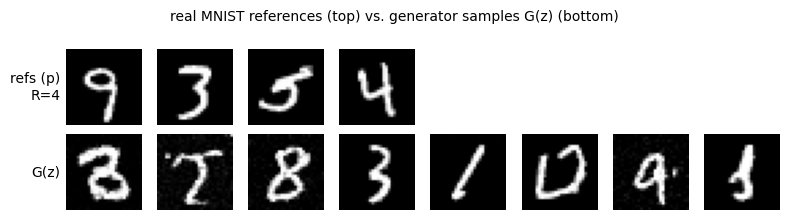

In [5]:
import matplotlib.pyplot as plt

def show_row(X, title, ax_row):
    """Render a (k, 784) batch in [-1,1] across ax_row; blanks any extra axes if k < len(ax_row)."""
    imgs = ((X.reshape(-1, H, W) + 1) / 2).clamp(0, 1)
    k = imgs.shape[0]
    for c, ax in enumerate(ax_row):
        if c < k:
            ax.imshow(imgs[c], cmap='gray', vmin=0, vmax=1)
        ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values():
            s.set_visible(False)
    ax_row[0].set_ylabel(title, rotation=0, ha='right', va='center', fontsize=10)

z0 = torch.randn(8, D, generator=torch.Generator().manual_seed(1))
x0 = G(z0)
fx0 = reward(x0)
print('G(z): finite', torch.isfinite(x0).all().item(), '| pixel range',
      (round(float(x0.min()), 2), round(float(x0.max()), 2)))
print('reward(G(z)):', [round(v, 2) for v in fx0.tolist()])

ncols = 8
fig, axes = plt.subplots(2, ncols, figsize=(ncols, 2.2))
show_row(x_refs[:ncols], f'refs (p)\nR={x_refs.shape[0]}', axes[0])
show_row(x0,             'G(z)',                          axes[1])
fig.suptitle('real MNIST references (top) vs. generator samples G(z) (bottom)', fontsize=10)
plt.tight_layout(); plt.show()

## 3. The $\lambda$ sweep — tempered SMC

The tilted temperatures $\lambda\in\{0.75, 1.0, 1.25\}$ are run with `smc_sample` + `PCNKernel`, reusing the exact machinery from the 2D notebooks — no changes for pixels. Rejuvenation length is **fully automatic** (`n_mcmc=None`, default stop policy): each level sweeps until the resampled particles decorrelate or $f$ plateaus. `final_resample=True` returns equal-weight draws from $\hat q_\lambda$.

The **$\lambda=0$** case is just $p$ itself, so we skip SMC and draw directly from $p$ (a batch of real MNIST), ranking them by $f$ in the next section — the untilted baseline.

> Slow cell on CPU: cost is dominated by the IEM reward ($(\texttt{N\_GAMMA}-1)\times R$ denoiser forwards per evaluation), and the automatic sweep count climbs on the hard high-$\lambda$ levels where pCN mixes slowly. With $R=4$, expect roughly 30–45 min for the three tilted $\lambda$.

In [6]:
from creativity_measure import adaptive_tempering_smc_sample, PCNKernel

LAMBDAS     = [0.75, 1.0, 1.25]               # tilted (creative) temperatures, run with SMC
N           = 16                              # SMC particles (CPU-small; raise on GPU)
ESS_TARGET  = 0.8
N_BASELINE  = 64                              # direct p-draws for the lambda=0 row

samples = {}                                  # lam -> particles X to rank/render
results = {}                                  # lam -> AdaptiveTemperingSMCResult (diagnostics), tilted lambdas only

# lambda = 0 is just p: draw directly (no SMC) and rank by f later ("weight it").
samples[0.0] = p.sample(N_BASELINE, seed=0)
print(f"lambda=0.00 (direct p-sample, N={N_BASELINE})  E[f]={float(reward(samples[0.0]).mean()):.2f}\n")

# tilted lambdas: automatic-length rejuvenation (n_mcmc=None, default stop policy)
print(f"{'lambda':>6} {'levels':>6} {'sweeps':>6} {'ESS_end':>8} {'E[f]':>7} {'sec':>6}   profile / stop reasons")
for lam in LAMBDAS:
    t = time.time()
    res = adaptive_tempering_smc_sample(reward, lam=lam, n_particles=N, kernel=PCNKernel(G, D),
                     n_mcmc=None, ess_target=ESS_TARGET, final_resample=True, seed=0)
    results[lam] = res
    samples[lam] = res.X
    ef = float(reward(res.X).mean())
    print(f"{lam:6.2f} {len(res.betas):6d} {sum(res.n_mcmc_history):6d} "
          f"{res.ess_history[-1]:8.1f} {ef:7.2f} {time.time()-t:6.0f}   "
          f"{res.n_mcmc_history}  {res.stop_reason_history}")

lambda=0.00 (direct p-sample, N=64)  E[f]=1.09

lambda levels sweeps  ESS_end    E[f]    sec   profile / stop reasons


  0.75      5     46     12.9    9.91    328   [10, 5, 5, 21, 5]  ['decorr', 'decorr', 'decorr', 'plateau', 'plateau']


  1.00      7    107     14.9   13.19    771   [10, 5, 5, 21, 30, 25, 11]  ['decorr', 'decorr', 'decorr', 'plateau', 'cap', 'plateau', 'plateau']


  1.25      8    131     12.9   15.01    902   [10, 5, 5, 21, 30, 25, 30, 5]  ['decorr', 'decorr', 'decorr', 'plateau', 'cap', 'plateau', 'cap', 'plateau']


## 4. Top creative samples per $\lambda$

We score each row's samples with the reward $f$ and take the top-$k$ — the *most creative* draws (highest expected IEM distance from real digits). The **$\lambda=0$ row** is the baseline: the most-novel draws from $p$ itself (real MNIST, ranked by $f$). The tilted rows should grow increasingly unusual / off-manifold as $\lambda$ rises.

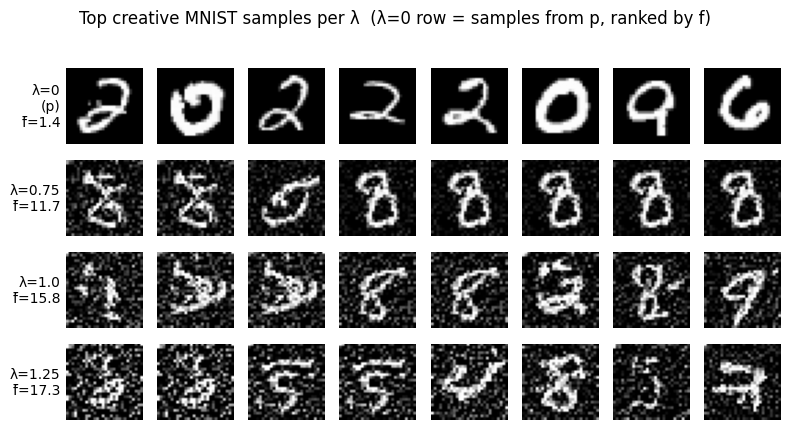

In [7]:
ROW_LAMBDAS = [0.0] + LAMBDAS                 # lambda=0 row is the direct p baseline
TOPK = 8
fig, axes = plt.subplots(len(ROW_LAMBDAS), TOPK, figsize=(TOPK, 1.05 * len(ROW_LAMBDAS)))
if len(ROW_LAMBDAS) == 1:
    axes = axes[None, :]
for r, lam in enumerate(ROW_LAMBDAS):
    X   = samples[lam]
    fx  = reward(X)                                      # per-sample creativity score
    order = fx.argsort(descending=True)                  # rank most-creative first
    top = X[order[:TOPK]]
    tag = 'λ=0\n(p)' if lam == 0.0 else f'λ={lam}'
    show_row(top, f'{tag}\nf̄={float(fx[order[:TOPK]].mean()):.1f}', axes[r])
fig.suptitle('Top creative MNIST samples per λ  (λ=0 row = samples from p, ranked by f)', y=1.02)
plt.tight_layout(); plt.show()

## Takeaways

- The algorithm doesn't work for pixel space, due to sparsity. Should use Latent-space models instead.